# Investment Assistant — slide replication

This notebook walks through the exact example from the *Investment Assistant* slide:

> **User:** "What's the current gold/copper ratio? Backtest buying when it crosses above the 200 DMA over the last 10 years."

The slide shows a Discord bot ("MCB") powered by a Claude API tool-use loop that orchestrates two tools — `query_market_data` (read-only SQL) and `backtest` — across three rounds:

| Round | Action |
|---|---|
| 1 | `query_market_data` with `WHERE ticker = 'GC=F/HG=F'` → **0 rows** (ratio tickers aren't stored directly) |
| 2 | Self-correction: rewrite as two subqueries `(gold close) / (copper close)` → 1 row, the current ratio |
| 3 | `backtest` with `tickers='GC=F/HG=F'`, `entry_condition='price_cross_above_sma_200'`, `exit_condition='price_cross_below_sma_200'`, `days=3650`, `timeframe='daily'` |

This notebook isolates the **deterministic primitives** — the database, the SQL tool, and the backtest engine. The Claude orchestration layer is intentionally not included; it's the wrapper around these primitives.

## Setup

`seed_ohlcv(..., source="auto")` tries Yahoo Finance first and falls back to a deterministic synthetic generator if the network can't reach it (sandboxed CI, offline, etc.). For real numbers, run this on a machine with internet access — the synthetic path is just for plumbing.

In [1]:
from investment_assistant import seed_ohlcv, query_market_data, backtest

counts = seed_ohlcv(tickers=["GC=F", "HG=F"], period="15y", source="auto")
counts

[seed] source=synthetic (yfinance unavailable)  rows={'GC=F': 3779, 'HG=F': 3779}


{'GC=F': 3779, 'HG=F': 3779}

## Round 1 — naive query for the ratio ticker

On the slide, Claude's first attempt is a literal lookup of `'GC=F/HG=F'` in the `ohlcv` table. The DB only stores per-ticker bars, so this comes back empty — the failure mode the slide highlights.

In [2]:
round1 = query_market_data(
    "SELECT close, date FROM ohlcv WHERE ticker = 'GC=F/HG=F' "
    "ORDER BY date DESC LIMIT 1"
)
round1

{'columns': ['close', 'date'], 'rows': [], 'row_count': 0}

## Round 2 — two-subquery rewrite

Same logic the slide shows: `(latest gold close) / (latest copper close)`.

In [3]:
round2 = query_market_data(
    """
    SELECT
        (SELECT close FROM ohlcv WHERE ticker = 'GC=F' ORDER BY date DESC LIMIT 1)
        /
        (SELECT close FROM ohlcv WHERE ticker = 'HG=F' ORDER BY date DESC LIMIT 1)
        AS ratio,
        (SELECT date FROM ohlcv WHERE ticker = 'GC=F' ORDER BY date DESC LIMIT 1)
        AS as_of
    """
)
ratio, as_of = round2["rows"][0]
print(f"Current GC=F/HG=F ratio: {ratio:.1f}  (as of {as_of})")

Current GC=F/HG=F ratio: 368.8  (as of 2026-04-24)


## Round 3 — 10Y backtest with the slide's exact parameters

Long when the ratio crosses above its 200-day moving average; flat when it crosses below.

In [4]:
result = backtest(
    tickers="GC=F/HG=F",
    entry_condition="price_cross_above_sma_200",
    exit_condition="price_cross_below_sma_200",
    days=3650,
    timeframe="daily",
)
result.metrics

{'lookback_days': 3650.0,
 'bars': 2609.0,
 'total_return': 1.2637899600277915,
 'buy_hold_return': -0.2567831085161072,
 'cagr': 0.08211438808019533,
 'buy_hold_cagr': -0.02825745708863281,
 'sharpe': 0.6274427471480065,
 'max_drawdown': -0.22790263320908566,
 'buy_hold_max_drawdown': -0.711975575245446,
 'trades': 21.0,
 'win_rate': 0.19047619047619047,
 'avg_trade_return': 0.04969957858190453}

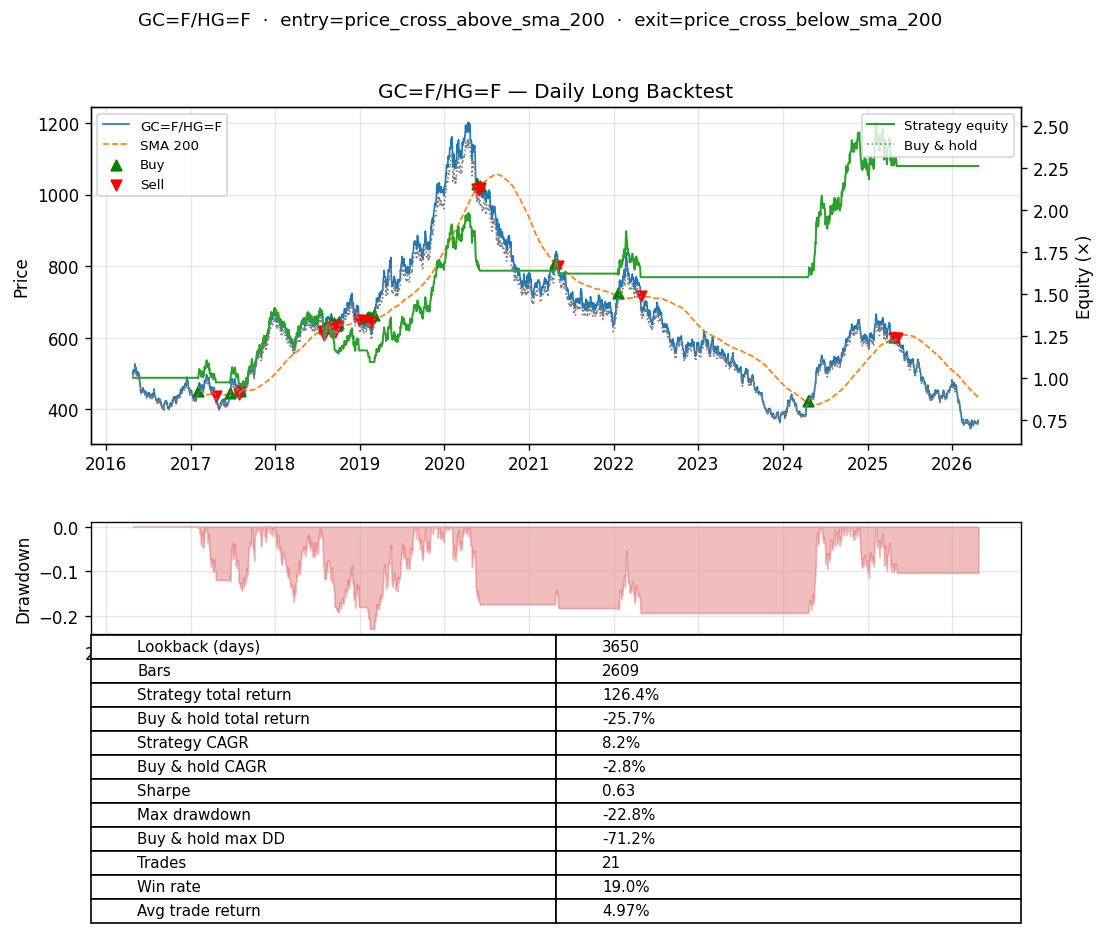

In [5]:
from IPython.display import Image
Image(filename=str(result.chart_path))

## Trades

One row per round-trip — entry/exit dates and the trade's return.

In [6]:
result.trades.head(10)

,entry_date,entry_price,exit_date,exit_price,return
0,2017-02-01,450.303103,2017-04-19,438.051610,-0.027207
1,2017-06-19,444.954773,2017-07-27,442.043195,-0.006544
2,2017-08-01,452.181120,2017-08-02,447.578704,-0.010178
3,2017-08-03,456.414545,2018-07-27,617.300605,0.352500
4,2018-07-30,625.871002,2018-07-31,606.252815,-0.031345
5,2018-08-08,629.772098,2018-08-28,626.643837,-0.004967
6,2018-08-29,645.132903,2018-09-11,626.436637,-0.028980
7,2018-09-12,640.770244,2018-09-14,616.127381,-0.038458
8,2018-09-20,636.279683,2018-09-21,630.566233,-0.008979
9,2018-09-25,634.943669,2018-09-27,632.508826,-0.003835


## What's not in this repo

The slide also describes the orchestration layer — a Discord bot, a Claude API tool-use loop with prompt caching, and the multi-round self-correction logic that turned Round 1's empty result into Round 2's rewritten query. None of that is here. The two functions `query_market_data` and `backtest` plus their JSON schemas (`QUERY_MARKET_DATA_SCHEMA` and `BACKTEST_SCHEMA` in `investment_assistant.py`) are the substrate that orchestration would sit on top of.